# Evaluate IRMAS And Film Test Sets

This notebook uses the functions in `src.test.test` to evaluate trained runs on:
- the IRMAS Part 1 test set
- the film test set in `data/test/a-touch-of-zen/`

Both evaluators read model metadata from the saved `run_config.yaml` in each run directory.

In [1]:
from pathlib import Path
import base64
import io
import uuid

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display
from sklearn.metrics import ConfusionMatrixDisplay

from src.test.test import evaluate_film_run, evaluate_irmas_part1_run

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)


def compact_predictions_table(predictions_df: pd.DataFrame) -> pd.DataFrame:
    true_labels = predictions_df["relevant_true_labels"].replace("", pd.NA).fillna(predictions_df["all_true_labels"])
    return predictions_df.assign(
        wav=predictions_df["wav"],
        true_labels=true_labels,
        pred_label=predictions_df["pred_top1_label"],
        pred_conf=predictions_df["pred_top1_conf"].round(4),
        pred_topk_labels=predictions_df["pred_topk_labels"],
    )[["wav", "true_labels", "pred_label", "pred_conf", "pred_topk_labels"]]


def summary_table(summary: dict, top_k: int) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {"metric": "model", "value": summary["model_name"]},
            {"metric": "dataset", "value": summary["dataset"]},
            {"metric": "samples", "value": summary["samples"]},
            {"metric": "top1_acc", "value": round(float(summary["top1_acc_relevant_labels"]), 4)},
            {"metric": f"top{top_k}_acc", "value": round(float(summary[f"top{top_k}_acc_relevant_labels"]), 4)},
            {"metric": "top1_micro_f1", "value": round(float(summary["top1_micro_f1"]), 4)},
            {"metric": "top1_macro_f1", "value": round(float(summary["top1_macro_f1"]), 4)},
        ]
    )


def dataframe_html(df: pd.DataFrame, max_rows: int | None = None) -> str:
    if df.empty:
        return "<p>No rows to display.</p>"

    show_df = df if max_rows is None else df.head(max_rows)
    note = ""
    if max_rows is not None and len(df) > max_rows:
        note = f"<p><em>Showing first {max_rows} of {len(df)} rows.</em></p>"
    return note + show_df.to_html(index=False, escape=False)


def confusion_html(name: str, confusion_df: pd.DataFrame) -> str:
    if confusion_df.empty:
        return "<p>No confusion matrix available.</p>"

    labels = confusion_df.columns.tolist()
    cm_counts = confusion_df.to_numpy(dtype=float)
    row_sums = cm_counts.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm_counts, row_sums, out=np.zeros_like(cm_counts), where=row_sums > 0)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    ConfusionMatrixDisplay(
        confusion_matrix=cm_counts.astype(int),
        display_labels=labels,
    ).plot(ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=90, values_format="d")
    axes[0].set_title(f"{name}: Confusion Matrix (Counts)")

    ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=labels,
    ).plot(ax=axes[1], cmap="Blues", colorbar=False, xticks_rotation=90, values_format=".2f")
    axes[1].set_title(f"{name}: Confusion Matrix (Row-Normalized)")

    plt.tight_layout()
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight")
    plt.close(fig)
    image_b64 = base64.b64encode(buffer.getvalue()).decode("utf-8")
    return (
        f'<img src="data:image/png;base64,{image_b64}" style="max-width: 100%; height: auto;" />'
        + confusion_df.to_html()
    )


def display_tabs(name: str, tabs: list[tuple[str, str]]) -> None:
    tab_group = f"tab-{uuid.uuid4().hex}"
    buttons = []
    panels = []

    for idx, (label, content) in enumerate(tabs):
        panel_id = f"{tab_group}-panel-{idx}"
        is_active = idx == 0
        buttons.append(
            f'<button class="codex-tab-button{" active" if is_active else ""}" '
            f'data-panel="{panel_id}" onclick="codexOpenTab(this)">{label}</button>'
        )
        display_style = "block" if is_active else "none"
        panels.append(
            f'<div id="{panel_id}" class="codex-tab-panel" style="display: {display_style};">{content}</div>'
        )

    html = f'''
    <style>
      .codex-tab-wrapper {{ margin: 1rem 0 2rem; }}
      .codex-tab-buttons {{ display: flex; gap: 0.5rem; flex-wrap: wrap; margin-bottom: 1rem; }}
      .codex-tab-button {{ border: 1px solid #c7ced9; background: #f4f6f8; border-radius: 8px; padding: 0.45rem 0.8rem; cursor: pointer; }}
      .codex-tab-button.active {{ background: #dce9f8; border-color: #8fb1db; }}
      .codex-tab-panel {{ padding: 0.5rem 0; }}
      .codex-tab-panel table {{ display: block; overflow-x: auto; white-space: nowrap; }}
    </style>
    <div class="codex-tab-wrapper" id="{tab_group}">
      <h2>{name}</h2>
      <div class="codex-tab-buttons">{''.join(buttons)}</div>
      {''.join(panels)}
    </div>
    <script>
      function codexOpenTab(button) {{
        const root = button.closest('.codex-tab-wrapper');
        root.querySelectorAll('.codex-tab-button').forEach((item) => item.classList.remove('active'));
        root.querySelectorAll('.codex-tab-panel').forEach((item) => item.style.display = 'none');
        button.classList.add('active');
        const panel = root.querySelector('#' + button.dataset.panel);
        if (panel) {{
          panel.style.display = 'block';
        }}
      }}
    </script>
    '''
    display(HTML(html))


def show_result(name: str, result: dict, top_k: int) -> None:
    summary = result["summary"]
    predictions_df = result["predictions_df"]
    confusion_df = result["confusion_df"]

    compact_df = compact_predictions_table(predictions_df)
    misses_df = compact_df.loc[predictions_df["top1_hit_relevant_labels"] == False].copy()
    if not misses_df.empty:
        misses_df = misses_df.sort_values("pred_conf", ascending=False).reset_index(drop=True)

    tabs = [
        ("Overview", dataframe_html(summary_table(summary, top_k))),
        ("Predictions", dataframe_html(compact_df, max_rows=100)),
        ("Errors", dataframe_html(misses_df, max_rows=50)),
        ("Confusion", confusion_html(name, confusion_df)),
    ]
    display_tabs(name, tabs)


In [2]:
IRMAS_MODEL_PATH = Path("src/models/saved_weights/irmas/irmas_single_label_mel_cnn")
FILM_MODEL_PATH = Path("src/models/saved_weights/chinese_single_label_mel_cnn_ft_irmas")

BATCH_SIZE = 16
NUM_WORKERS = 0
TOP_K = 3
MAX_SAMPLES = None
DEVICE = "auto"

IRMAS_TEST_ROOT_OVERRIDE = None
FILM_TEST_ROOT_OVERRIDE = None



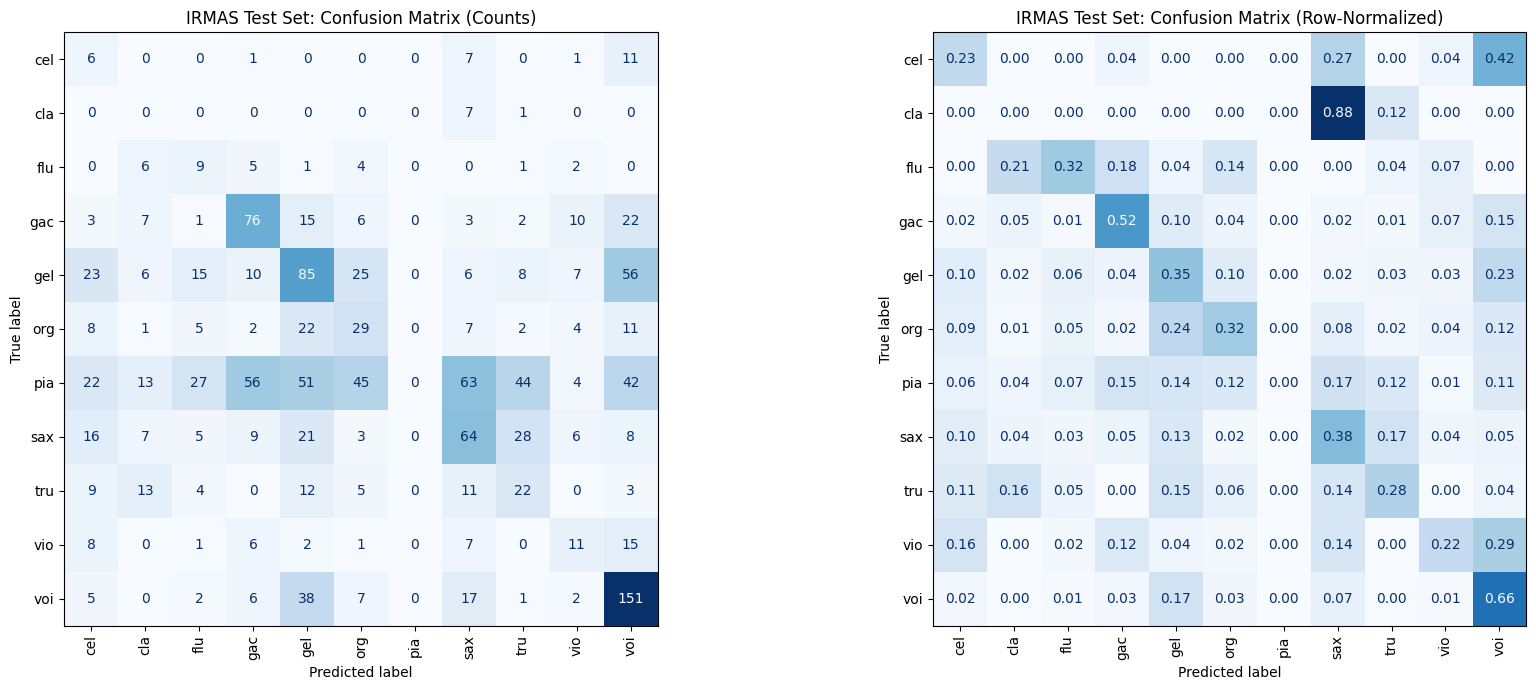

In [3]:
irmas_result = evaluate_irmas_part1_run(
    IRMAS_MODEL_PATH,
    test_root_override=IRMAS_TEST_ROOT_OVERRIDE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    top_k=TOP_K,
    max_samples=MAX_SAMPLES,
    device=DEVICE,
    show_progress=True,
)

show_result("IRMAS Test Set", irmas_result, TOP_K)



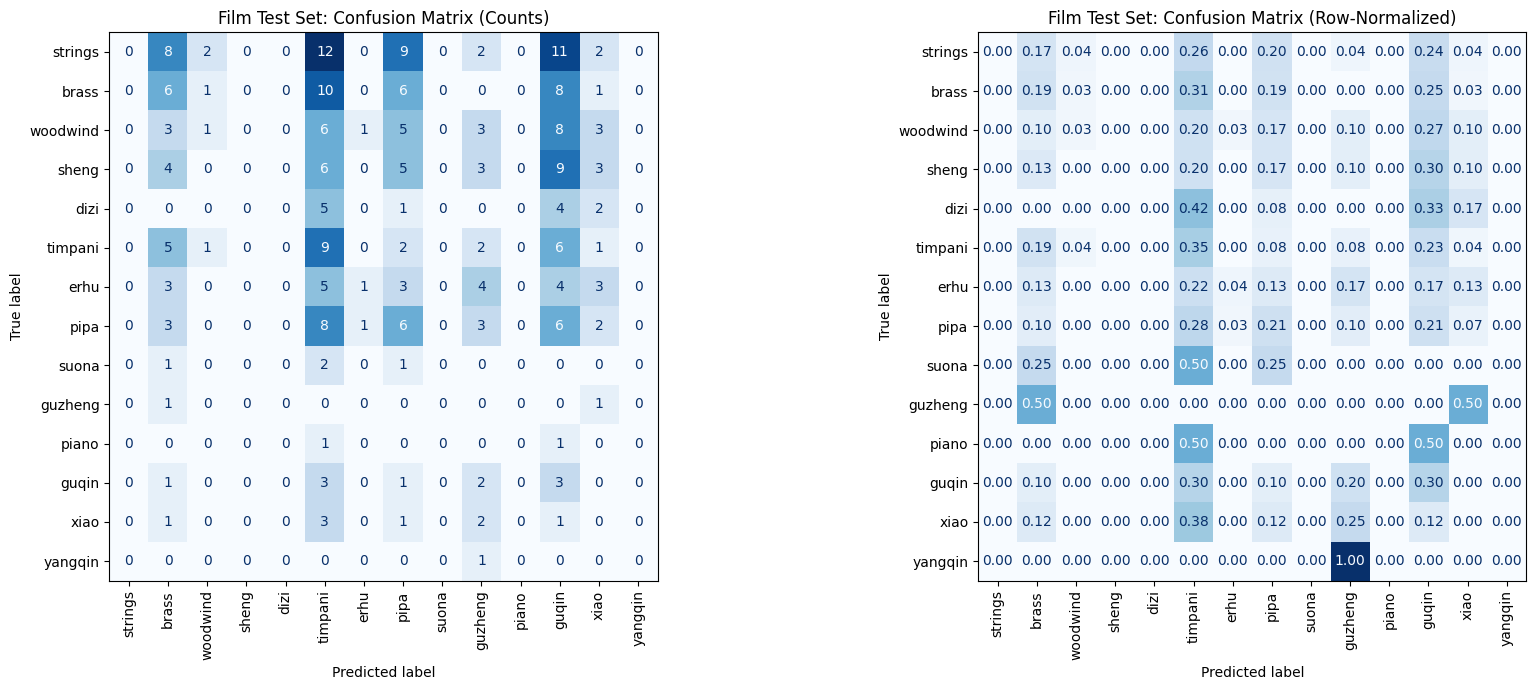

In [4]:
film_result = evaluate_film_run(
    FILM_MODEL_PATH,
    test_root_override=FILM_TEST_ROOT_OVERRIDE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    top_k=TOP_K,
    max_samples=MAX_SAMPLES,
    device=DEVICE,
    show_progress=True,
)

show_result("Film Test Set", film_result, TOP_K)
